###Paso 1: Cargar el dataset
Ejecuta el siguiente código para importar las librerías y cargar el dataset:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')


In [3]:
# Cargar dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)


In [4]:
# Primeras filas
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Pregunta 1:** ¿Cuántas filas y cuántas columnas tiene el dataset? Usa df.shape para verificar.


In [5]:
# Respuesta
df.shape

(7043, 21)

###Paso 2: Conocer la estructura del dataset
Ejecuta estos comandos para entender los tipos de datos:


In [6]:
# Información general del dataset
df.info()

# Tipos de variables
df.dtypes.value_counts()

# Nombres de las columnas
print(df.columns.tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Pregunta 2:** ¿Cuántas variables numéricas y cuántas categóricas identificas? Escribe 3 ejemplos de cada tipo.

**Respuesta:**
Se identifican 3 variables numéricas (SeniorCitizen, tenure y MonthlyCharges) y 18 variables categóricas (como gender, Contract y PaymentMethod).


**Pregunta 3:** ¿Qué representa cada fila del dataset? ¿Qué representa la columna "Churn"?

**Respuesta:** Cada fila del dataset representa un cliente individual de la empresa, junto con sus características (datos demográficos, servicios contratados y comportamiento). Por otro lado, la columna Churn representa si el cliente abandonó o no el servicio

###Paso 3: Limpieza inicial y- estadísticas descriptivas
Antes de calcular estadísticas, debemos corregir un problema conocido del dataset: la columna TotalCharges contiene valores que no son numéricos (espacios en blanco). Primero limpiamos y luego analizamos:


In [7]:
# Codificar Churn como numérico para análisis de correlación
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [8]:
# Estadísticas descriptivas (ahora TotalCharges aparece correctamente)
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,Churn_num
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,0.265370
std,0.368612,24.559481,30.090047,0.441561
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,0.000000
50%,0.000000,29.000000,70.350000,0.000000
75%,0.000000,55.000000,89.850000,1.000000
max,1.000000,72.000000,118.750000,1.000000


In [9]:
# Verificar valores nulos en todo el dataset
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Pregunta 4:** ¿Hay valores nulos en el dataset? ¿En qué columna(s)? ¿Cuántos son?

**Respuesta:** No hay valores nulos en el dataset después de la limpieza. Inicialmente, la columna TotalCharges tenía valores faltantes (convertidos a NaN), pero fueron tratados correctamente, quedando 0 valores nulos en todas las columnas.

**Pregunta 5:** ¿Cuál es el promedio de tenure (meses de antigüedad)? ¿Y la mediana? ¿Qué te dice la diferencia entre ambas?

**Respuesta:** El promedio de tenure es aproximadamente 32 meses y la mediana es 29 meses. La diferencia indica que hay algunos clientes con mayor antigüedad que elevan el promedio, lo que sugiere una ligera asimetría hacia la derecha en la distribución.

###Paso 4: Distribución de la variable objetivo
Analiza cómo se distribuye la variable Churn:


In [10]:
# Distribución de Churn
print(df['Churn'].value_counts())
print(f'\nPorcentaje de churn: {df["Churn"].value_counts(normalize=True)*100}')


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de churn: Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


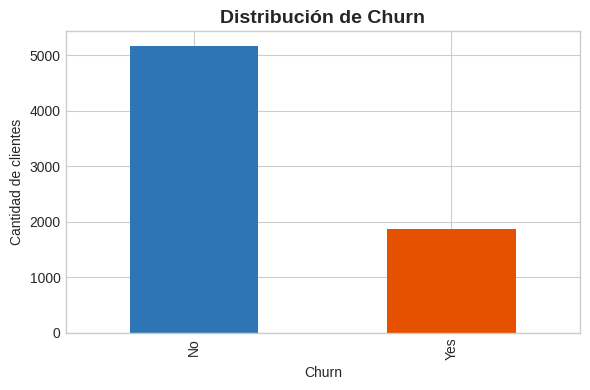

In [11]:
# Gráfico de barras
fig, ax = plt.subplots(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['#2E75B6', '#E65100'], ax=ax)
ax.set_title('Distribución de Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()


**Pregunta 6:** ¿El dataset está balanceado (las dos clases tienen cantidades similares) o desbalanceado? ¿Qué porcentaje de clientes canceló su contrato? ¿Por qué es importante saber esto antes de entrenar un modelo?

**Respuesta:** El dataset está desbalanceado, ya que hay muchos más clientes que no cancelaron (No) que los que sí cancelaron (Yes). Aproximadamente, el 26.54% de los clientes canceló su contrato, mientras que el 73.46% se mantuvo. Asimismo es importante conocer esto antes de entrenar un modelo porque el desbalance puede hacer que el modelo se sesgue hacia la clase mayoritaria, reduciendo su capacidad para detectar correctamente a los clientes que cancelan (churn).

###Paso 5: Visualización exploratoria
Genera las siguientes visualizaciones para explorar relaciones en los datos:


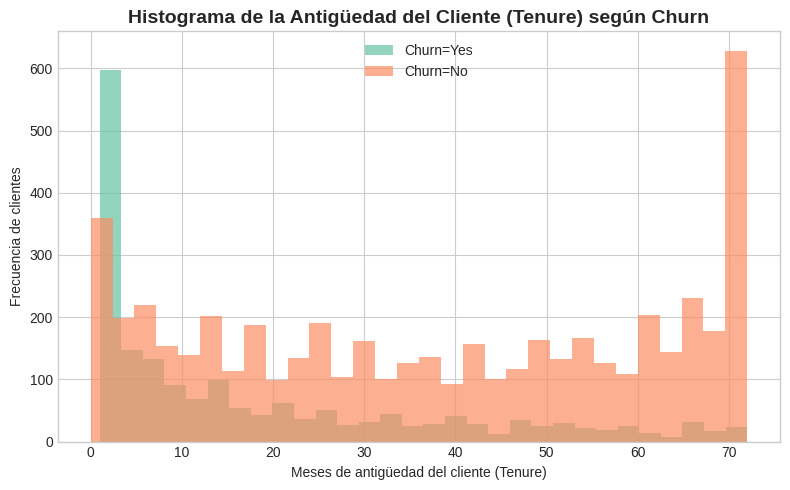

In [12]:
# Histograma de tenure por Churn
fig, ax = plt.subplots(figsize=(8, 5))
df[df['Churn']=='Yes']['tenure'].hist(alpha=0.7, label='Churn=Yes', bins=30, ax=ax)
df[df['Churn']=='No']['tenure'].hist(alpha=0.7, label='Churn=No', bins=30, ax=ax)
ax.set_title('Histograma de la Antigüedad del Cliente (Tenure) según Churn',fontsize=14, fontweight='bold')
ax.set_xlabel('Meses de antigüedad del cliente (Tenure)')
ax.legend()
ax.set_ylabel('Frecuencia de clientes')
plt.tight_layout()
plt.show()


Text(0, 0.5, 'Cargo mensual (MonthlyCharges)')

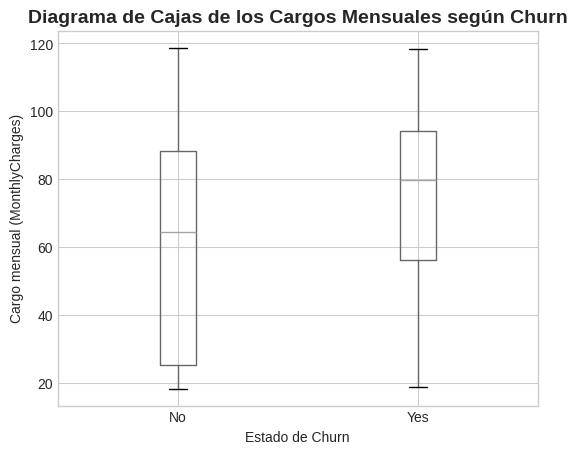

In [13]:
# Diagrama de cajas de MonthlyCharges por Churn
fig, ax = plt.subplots(figsize=(6, 5))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax)
ax.set_title('Diagrama de Cajas de los Cargos Mensuales según Churn',
             fontsize=14, fontweight='bold')
plt.suptitle('')
ax.set_xlabel('Estado de Churn')
ax.set_ylabel('Cargo mensual (MonthlyCharges)')


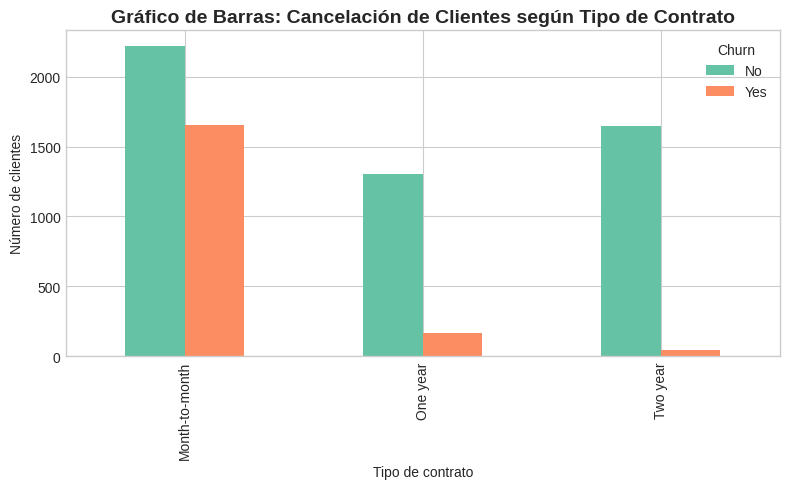

In [14]:
# Churn por tipo de contrato
fig, ax = plt.subplots(figsize=(8, 5))
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar', ax=ax)
ax.set_title('Gráfico de Barras: Cancelación de Clientes según Tipo de Contrato',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de contrato')
ax.set_ylabel('Número de clientes')
plt.tight_layout()
plt.show()


**Pregunta 7:** Observando el histograma de tenure: ¿Los clientes que cancelan tienden a tener más o menos antigüedad? ¿Qué hipótesis podrías formular?

**Respuesta:** Los clientes que cancelan tienden a tener menor antigüedad (tenure). La mayoría de los casos de churn se concentran en los primeros meses.

Hipótesis: los clientes nuevos son más propensos a cancelar porque aún no están fidelizados o no están satisfechos con el servicio inicial.

**Pregunta 8:** Observando el boxplot de MonthlyCharges: ¿Los clientes que cancelan pagan más o menos por mes? ¿Qué podría explicar esto?

**Respuesta:** Los clientes que cancelan tienden a pagar cargos mensuales más altos, esto podría explicarse porque los precios elevados generan mayor insatisfacción o porque estos clientes tienen más servicios, lo que aumenta el costo y la probabilidad de cancelar.

**Pregunta 9:** ¿Qué tipo de contrato tiene mayor tasa de churn? ¿Por qué tiene sentido desde el punto de vista del negocio?

**Respuesta:** El tipo de contrato con mayor churn es Month-to-month.
Esto tiene sentido porque estos clientes no tienen compromiso a largo plazo y pueden cancelar fácilmente en cualquier momento, a diferencia de los contratos anuales o de dos años que generan mayor retención.

###Paso 6: Matriz de correlación
Genera una matriz de correlación para las variables numéricas:


In [15]:
# Seleccionar solo variables numéricas (incluye Churn_num)
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()


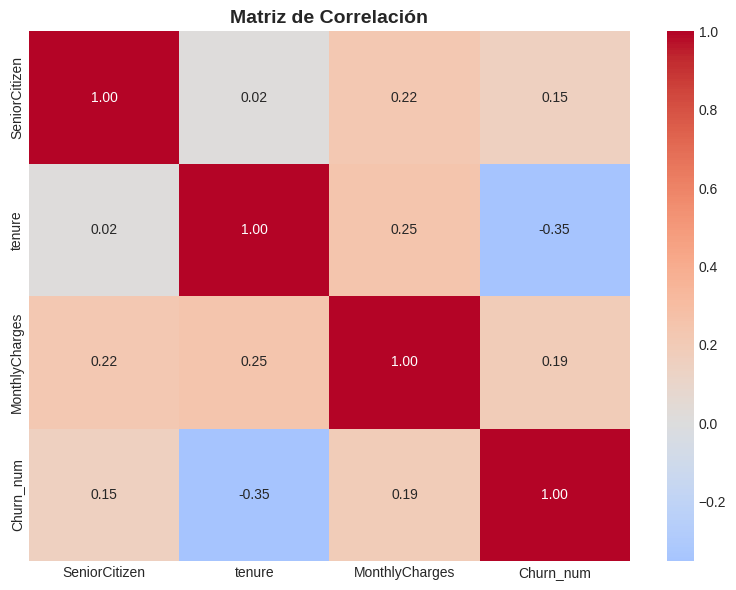

In [16]:
# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Pregunta 10:** ¿Qué variables muestran mayor correlación con Churn_num?
¿La relación es positiva o negativa? ¿Qué interpretación de negocio puedes hacer?

**Respuesta:** La variable que muestra mayor correlación con Churn_num es tenure, con una correlación negativa (-0.35), lo que indica que mientras mayor es la antigüedad del cliente, menor es la probabilidad de que cancele.

También se observa una correlación positiva débil con MonthlyCharges (0.19) y SeniorCitizen (0.15), lo que sugiere que clientes con mayores cargos mensuales o adultos mayores tienen una ligera mayor probabilidad de cancelar.

Por otro lado, se podria interpretar que los clientes nuevos son más propensos a abandonar el servicio, mientras que los clientes antiguos tienden a ser más leales. Además, precios más altos podrían influir en la decisión de cancelación.

##Actividad 3: Caso de estudio — Análisis para la toma de decisiones

###Contexto del caso:

Eres analista de datos junior en TelcoPerú, una empresa de telecomunicaciones. Tu jefe te ha pedido un informe preliminar sobre la situación del churn de clientes. Aún no vas a construir modelos predictivos (eso vendrá en semanas posteriores), pero necesitas presentar los hallazgos de tu exploración inicial para que el equipo de negocio tome decisiones.
Entregable esperado: Responde las siguientes preguntas en celdas de texto (Markdown) de tu notebook de Colab.


**Pregunta A:** ¿Este problema de negocio (predecir churn) es de clasificación, regresión o clustering? Justifica tu respuesta.

**Respuesta:** Este problema es de clasificación, ya que se busca predecir una variable categórica (Churn) que tiene dos valores posibles: Yes o No. Es decir, el modelo debe clasificar a los clientes según si cancelarán o no el servicio.


**Pregunta B:** Basado en tu exploración, ¿cuáles son las 3 variables que consideras más importantes para predecir el churn? Justifica con los gráficos que generaste.

**Respuesta:**

Las 3 variables más importantes para predecir el churn son:

* tenure: porque los clientes con menor antigüedad tienen mayor probabilidad de cancelar (según el histograma y la correlación negativa).

* MonthlyCharges: los clientes que pagan más tienden a cancelar más (observado en el boxplot).

* Contract: los contratos mensuales presentan mayor churn en comparación con contratos anuales o de dos años (según el gráfico de barras).

**Pregunta C:** ¿Qué fase del proceso KDD acabas de realizar en este laboratorio? Describe brevemente cada paso que seguiste.

**Respuesta:**

La fase realizada corresponde a la Exploración y Comprensión de los Datos (EDA) dentro del proceso KDD. Los pasos realizados fueron:

1. Selección de datos: uso del dataset de clientes.

2. Limpieza de datos: conversión de TotalCharges a numérico y manejo de valores nulos.

3. Transformación de datos: creación de la variable Churn_num.

4. Exploración de datos: análisis estadístico, visualizaciones y correlaciones para entender patrones.

**Pregunta D:** Si fueras a construir un modelo predictivo (en semanas futuras), ¿sería aprendizaje supervisado o no supervisado? ¿Por qué?

**Respuesta:** Sería un problema de aprendizaje supervisado, porque se cuenta con una variable objetivo (Churn) previamente etiquetada. El modelo aprenderá a partir de estos datos para predecir el comportamiento de nuevos clientes.

**Pregunta E:** Escribe 3 recomendaciones de negocio para TelcoPerú basadas únicamente en lo que observaste en los datos. No necesitas modelos, solo tus observaciones.

**Respuesta:**

1. Implementar estrategias de fidelización para clientes nuevos, especialmente en sus primeros meses.

2. Revisar la estructura de precios o beneficios, ya que los clientes con mayores cargos mensuales tienden a cancelar más.

3. Promover contratos de largo plazo (anuales o de dos años) para reducir la tasa de cancelación.

##Conclusiones

* La antigüedad del cliente (tenure) es un factor clave en la retención, mostrando una relación inversa con el churn.

* El dataset presenta desbalance en la variable objetivo, lo cual es importante considerar para futuros modelos predictivos.

* El análisis exploratorio permite identificar patrones importantes sin necesidad de modelos, facilitando la toma de decisiones iniciales.